In [29]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import seaborn as sns
villager_df = pd.read_csv('villagers.csv')
rank_df = pd.read_csv('rankings.csv')

conn = sqlite3.connect(':memory:')
villager_df.to_sql('villagers', conn, index=False)
rank_df.to_sql('ranking', conn, index=False)

413

## **Background**

While I may not be as big into Animal Crossing as I was during quarantine (New Horizons came out a day before my birthday), it's still an interesting game to me, partially because of the community it's accumulated. The villagers in New Horizons are much less unique to eachother than in prior series entries, meaning there are less factors that could result in their popularity. There are eight total personalities, and 163 villagers, so once you've spoken to a villager with each personality, you've basically spoken to them all. I want to see if any observable factors correlate with villager popularity, like personality archetype or species- for example, are cat villagers more popular than rabbits? Do players enjoy villagers with certain hobbies? I understand a lot of popularity boils down to "they're cute", but besides cuteness not being measurable, I'm curious to see what else has to do with it.

## **Setup**

The "villagers" table columns that I will be using are each villager's name, species, gender, personality from 1 of 8 options, hobby (idle animation), birthday, catchphrase (short phrases that they say at the end of sentences), favorite song, and two columns for their style, which determines what they wear and like to receive. I'll be combining this with a separate dataset of an aggregated popularity ranking of the villagers, which not only lists their individual rank, but divides the list into groups for easier sorting.

## **Data Cleaning**

It turns out that the ranking column in the initial rankings CSV only had the villagers ranked in their tiers, and not as a whole- so there were 6 number 1s, which caused a whole host of issues. I preserved this column as "TierRank", and added "Overall Rank" for the rankings as a whole. I also had to adjust the column headers in the villagers CSV, as SQL won't take titles with spaces in them.

# **Questions**

In [30]:
species = pd.read_sql_query("""
    SELECT ranking.Name, ranking.OverallRank, villagers.Name, villagers.Species
    FROM ranking
    JOIN villagers
        ON ranking.Name = villagers.Name
    ORDER BY OverallRank ASC  
""", conn)
species

,Name,OverallRank,Name,Species
0,Raymond,1,Raymond,Cat
1,Marshal,2,Marshal,Squirrel
2,Sherb,4,Sherb,Goat
3,Ankha,7,Ankha,Cat
4,Zucker,8,Zucker,Octopus
...,...,...,...,...
381,Rocco,394,Rocco,Hippo
382,Bettina,395,Bettina,Mouse
383,Boris,396,Boris,Pig
384,Bitty,397,Bitty,Hippo


## How popular does each species tend to be? Are there any noticeable outliers for their species?

### Part 1 - Range of Popularity

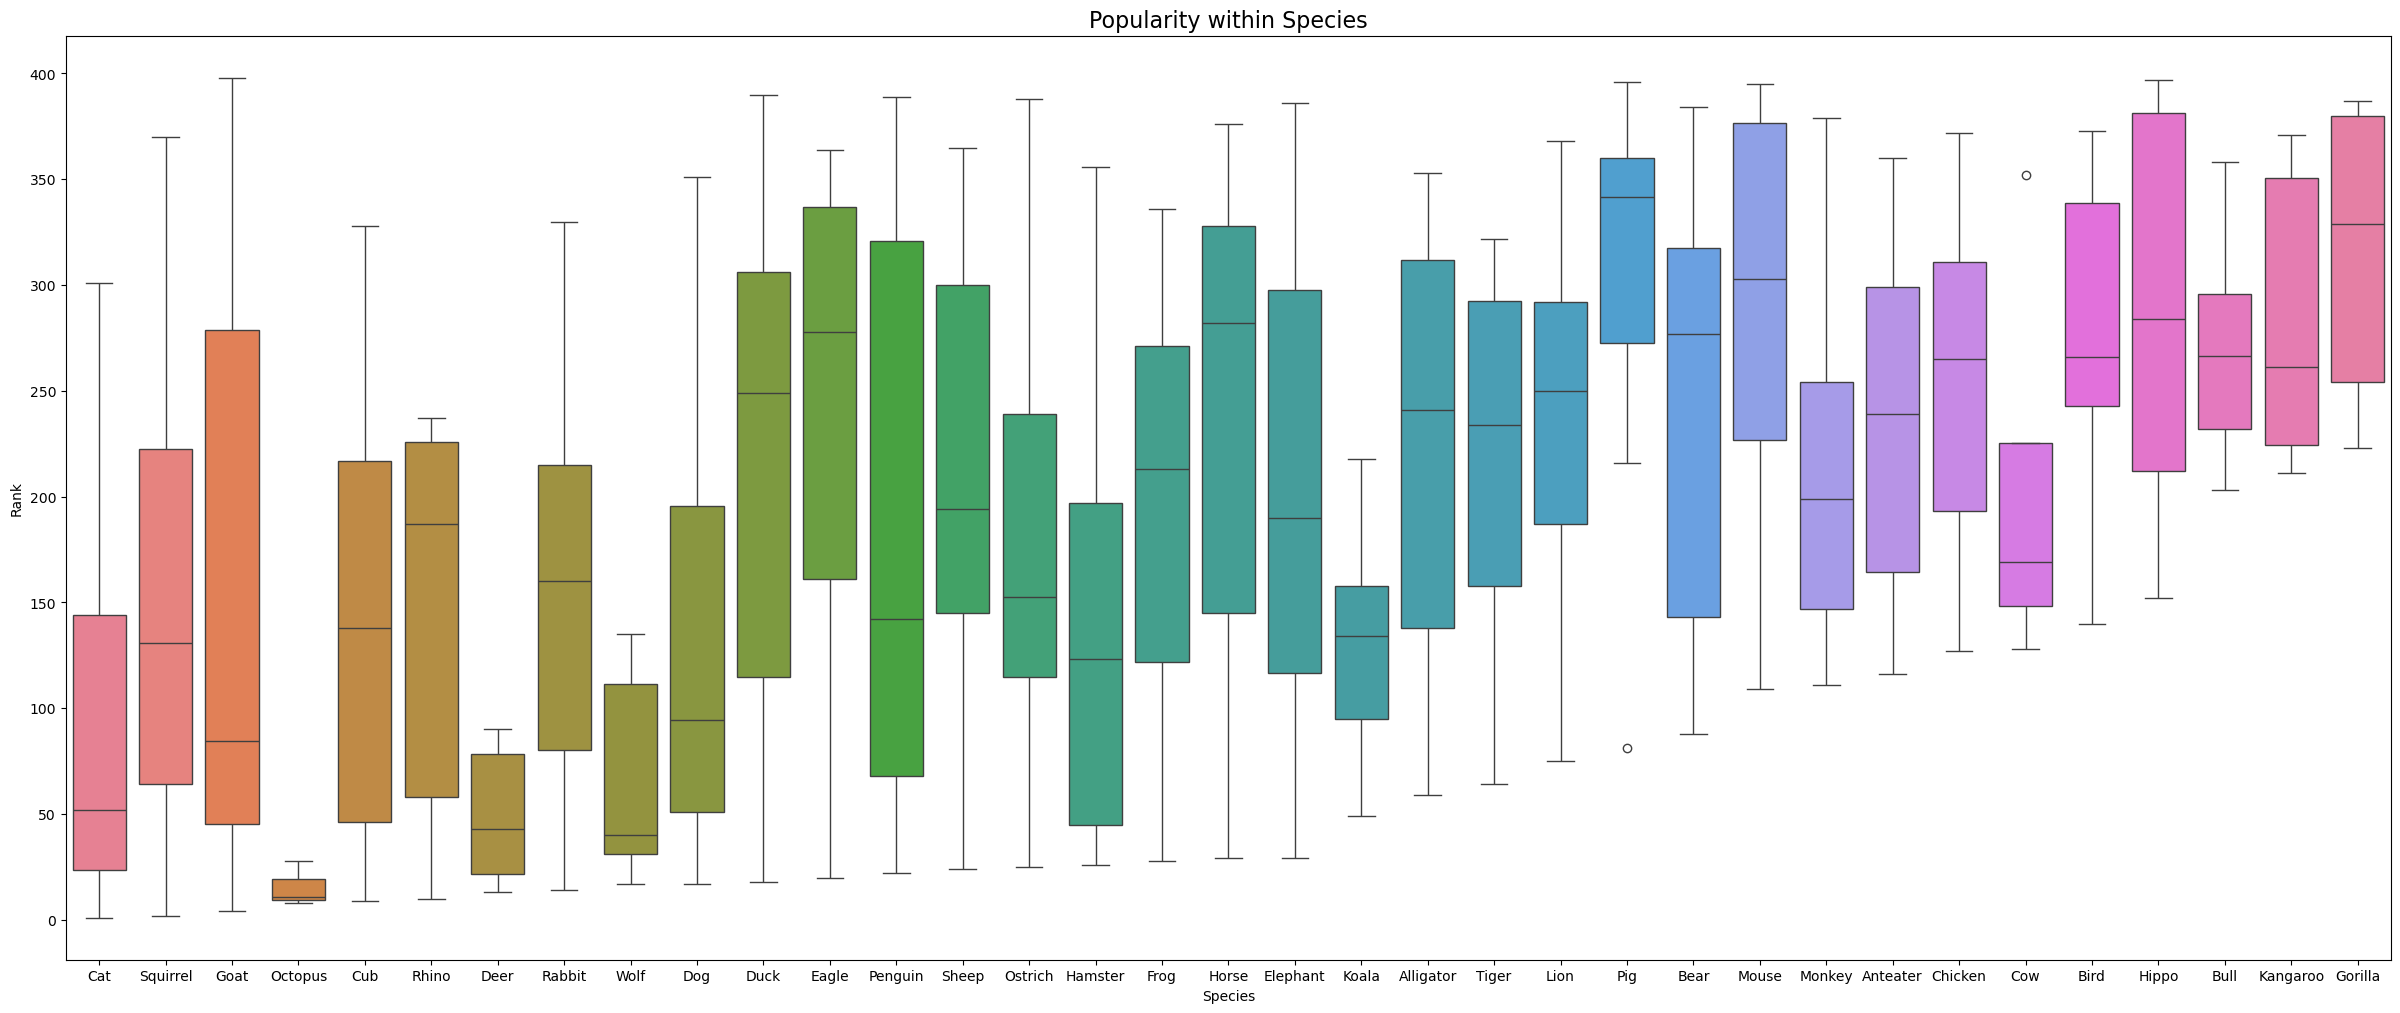

In [31]:
plt.figure(figsize=(30, 12))
sns.boxplot(x='Species', y='OverallRank', data=species, hue='Species')
plt.title('Popularity within Species', fontsize=16)
plt.xlabel('Species')
plt.ylabel('Rank')
plt.show()

The box plot is helpful in determining the range of popularity and which species may have outliers- for example, Agnes ranks 81, while the second-most popular pig, Gala, is all the way at 216. In contrast, Tipper the cow ranks 183, but the cow below her, Naomi, is all the way at 352!

### Part 2 - Average Species Popularity

In [32]:
speciesavg = pd.read_sql_query("""
    SELECT AVG(ranking.OverallRank) AS average_rank, villagers.Species
    FROM ranking
    JOIN villagers
        ON ranking.Name = villagers.Name
    GROUP BY Species
    ORDER BY average_rank ASC
""", conn)

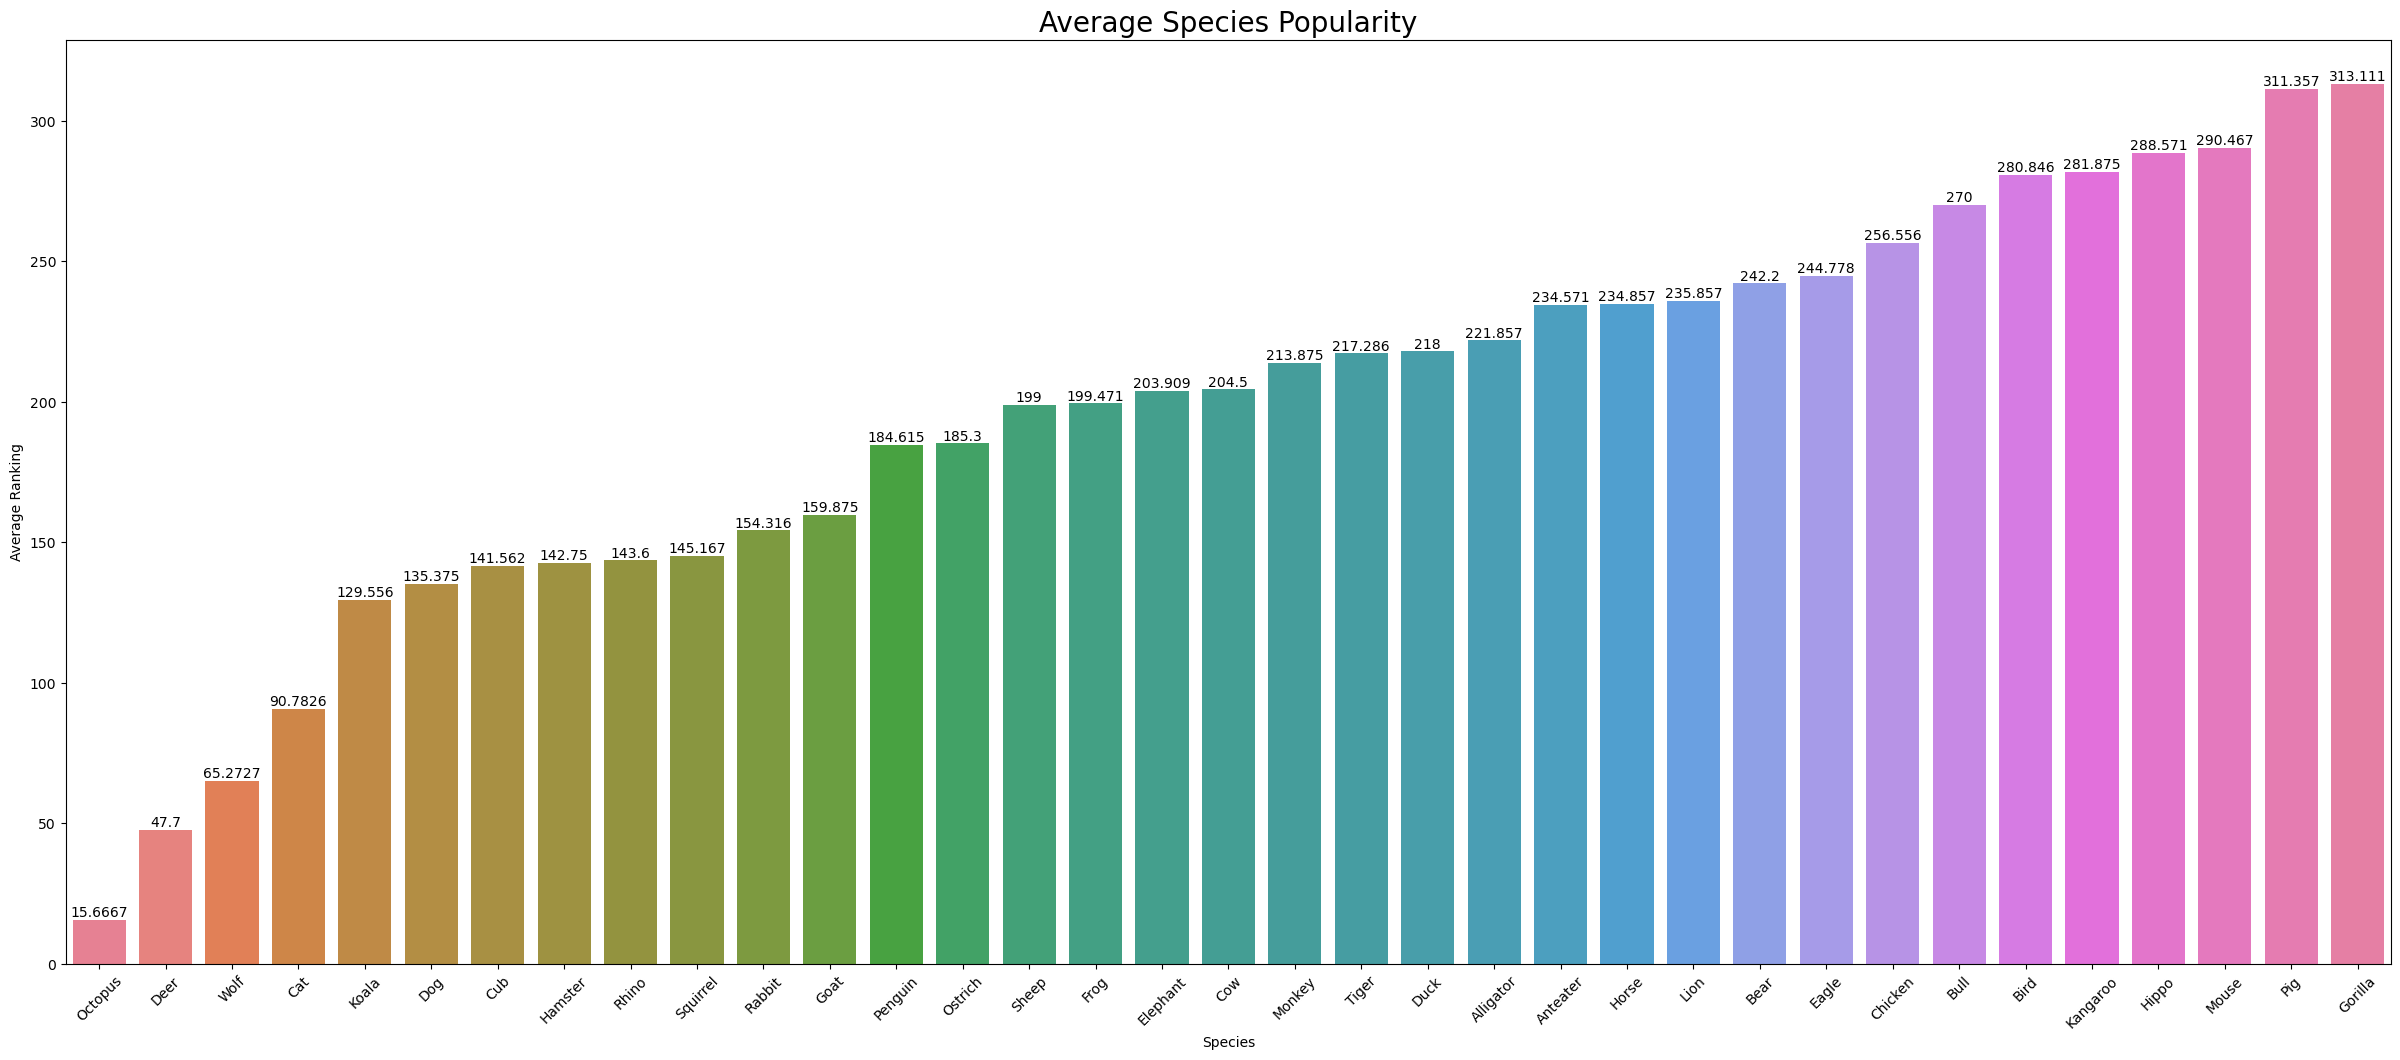

In [77]:
plt.figure(figsize=(30, 12))
avp = sns.barplot(data=speciesavg, x='Species', y='average_rank', hue='Species', legend=False)
for i in avp.containers:
    avp.bar_label(i)
plt.title('Average Species Popularity', fontsize=20)
plt.xlabel('Species')
plt.ylabel('Average Ranking')
plt.xticks(rotation=45)
plt.show()

This graph is a followup to the previous, exploring the average popularity of each species, rather than the mean. I want the bars to be labelled with the species, but we'll get there when we get there- for now, you can cross-reference the data frame. I have more questions to ask, (like popularity vs. birth month, style/personality, etc.) but setting up these two graphs was already such a headache, haha. Part of me wonders if I should merge the ranking table into the villagers table externally just so I have one, easy table to work with, but at least I know how to use join functions in SQL now!

# How does style combination affect popularity?

Each villager has a two "styles", a primary and secondary preference. This means that the order of style does matter- a villager with Cute/Cool style 1/2 won't prefer the same things the same way as a villager with Cool/Cute

In [34]:
stylescombo = pd.read_sql_query("""
    SELECT AVG(ranking.OverallRank) AS average_rank, villagers.Style1, villagers.Style2
    FROM ranking
    JOIN villagers
        ON ranking.Name = villagers.Name
    GROUP BY Style1, Style2
    ORDER BY average_rank ASC
""", conn)

In [35]:
heatmap_data = stylescombo.pivot_table(values='average_rank', index='Style2', columns='Style1')
heatmap_data.fillna(0)

Style1,Active,Cool,Cute,Elegant,Gorgeous,Simple
Style2,,,,,,
Active,243.833333,180.727273,171.500000,322.000000,191.000000,249.666667
Cool,227.222222,243.444444,0.000000,189.083333,201.750000,232.750000
Cute,155.800000,0.000000,83.062500,141.285714,137.666667,115.870968
Elegant,295.000000,159.000000,196.066667,104.000000,267.500000,223.818182
Gorgeous,323.500000,221.500000,265.571429,216.961538,90.000000,194.250000
Simple,236.920000,225.920000,138.352941,167.166667,42.666667,162.406250


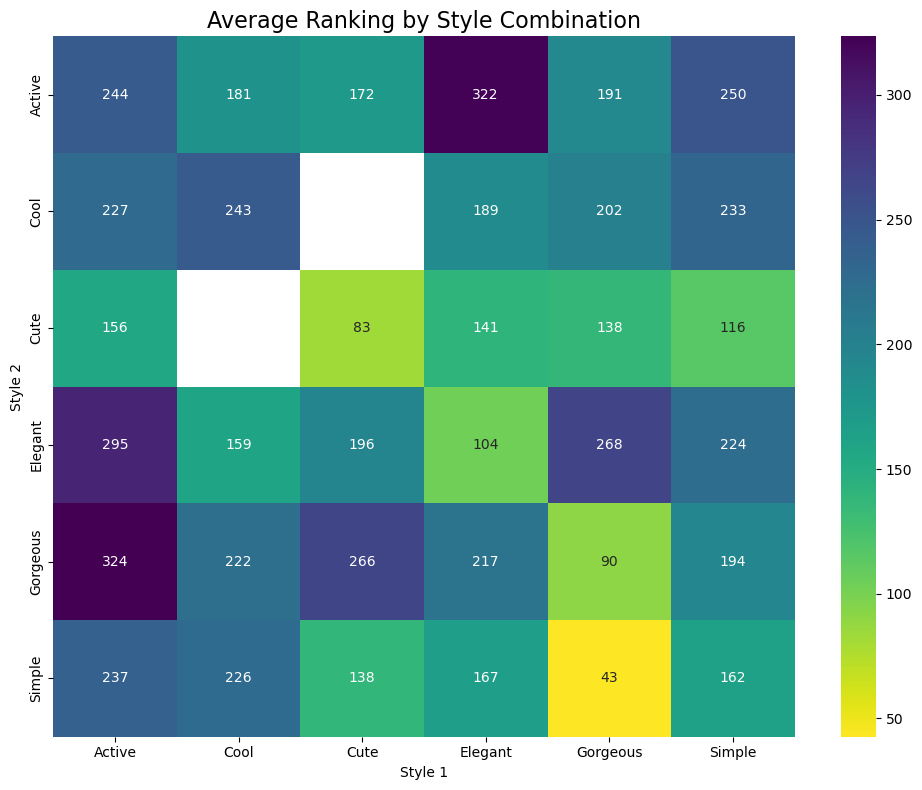

In [36]:
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, cmap='viridis_r', annot=True, fmt='.0f')
plt.title('Average Ranking by Style Combination', fontsize=16)
plt.xlabel('Style 1')
plt.ylabel('Style 2')
plt.tight_layout()
plt.show()

This is a heat map of the average popularity of the aforementioned style combinations, with a lighter color corresponding to a higher rank. Despite using Cute/Cool as my example, the two styles surprisingly never intersect, leading to empty cells.

Below are two average queries, which find the average ranking for each style, in their primary and secondary slots. This, along with the average of both averages will be compared to one another.

In [37]:
styleavg1 = pd.read_sql_query("""
    SELECT AVG(ranking.OverallRank) AS average_rank, villagers.Style1
    FROM ranking
    JOIN villagers
        ON ranking.Name = villagers.Name
    GROUP BY Style1
    ORDER BY average_rank ASC
""", conn)
styleavg1

,average_rank,Style1
0,156.396825,Cute
1,182.560345,Simple
2,197.222222,Elegant
3,211.940299,Cool
4,214.947368,Gorgeous
5,232.333333,Active


In [38]:
styleavg2 = pd.read_sql_query("""
    SELECT AVG(ranking.OverallRank) AS average_rank, villagers.Style2
    FROM ranking
    JOIN villagers
        ON ranking.Name = villagers.Name
    GROUP BY Style2
    ORDER BY average_rank ASC
""", conn)
styleavg2

,average_rank,Style2
0,114.548387,Cute
1,187.509259,Simple
2,219.458333,Active
3,220.241379,Cool
4,221.857143,Elegant
5,224.351852,Gorgeous


In [39]:
style = pd.DataFrame({
    'Style1': [156.40, 182.56, 197.22, 211.94, 214.95, 232.33],
    'Style2': [114.55, 187.51, 221.85, 220.24, 224.35, 219.46],
}, index=['Cute', 'Simple', 'Elegant', 'Cool', 'Gorgeous', 'Active'])
style['Average'] = (style['Style1'] + style['Style2']) / 2
style

,Style1,Style2,Average
Cute,156.40,114.55,135.475
Simple,182.56,187.51,185.035
Elegant,197.22,221.85,209.535
Cool,211.94,220.24,216.090
Gorgeous,214.95,224.35,219.650
Active,232.33,219.46,225.895


<Figure size 1000x600 with 0 Axes>

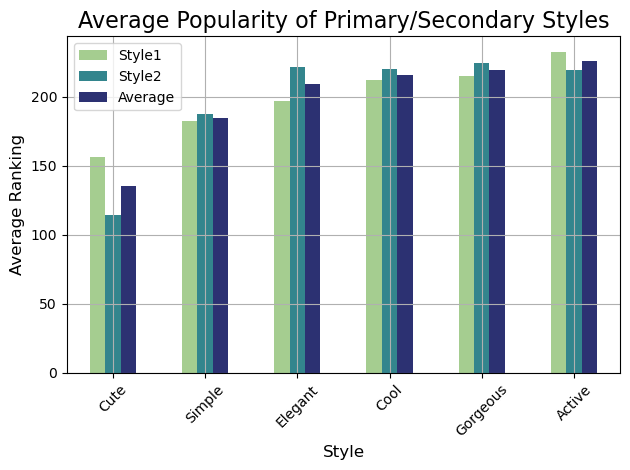

In [40]:
plt.figure(figsize=(10, 6))
style.plot(kind='bar', grid=True, cmap='crest')
plt.title('Average Popularity of Primary/Secondary Styles', fontsize=16)
plt.xlabel('Style', fontsize=12)
plt.ylabel('Average Ranking', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

This chart lays out the popularity of each style, as a primary and secondary style, as well as the average of the two. Cute and Active are the only two styles that are more popular as a primary style, even though they're the most and least popular primary styles respectively.

# How are personality types distributed? Does personality affect popularity?

Each villager has one of four personality types available to their gender, with eight types in total. There's Peppy, Snooty, Normal (Sweet), and Big Sister (Uchi) for females, and Jock, Cranky, Lazy, and Smug for males.

In [115]:
perstot = pd.read_sql_query("""
    SELECT AVG(ranking.OverallRank) AS average_rank, COUNT(ranking.OverallRank) AS total_villagers, villagers.Personality
    FROM ranking
    JOIN villagers
        ON ranking.Name = villagers.Name
    GROUP BY Personality
    ORDER BY average_rank ASC
""", conn)

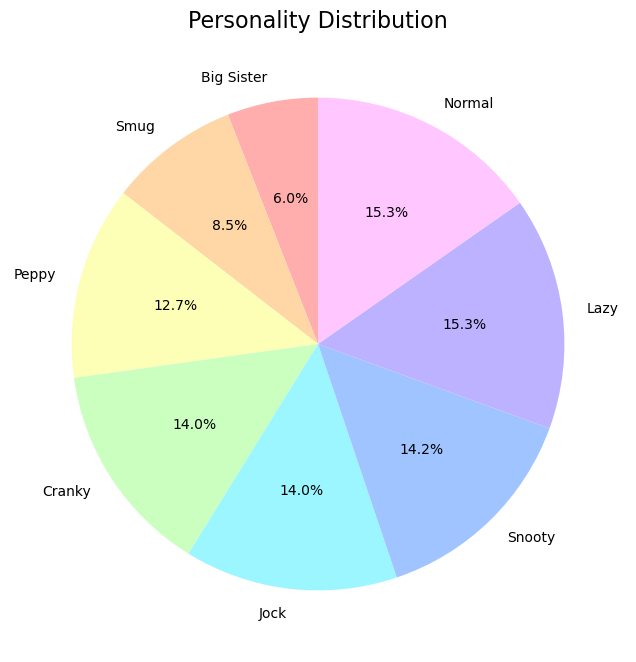

In [65]:
data = perstot.total_villagers
labels = ['Big Sister', 'Smug', 'Peppy', 'Cranky', 'Jock', 'Snooty', 'Lazy', 'Normal']
plt.figure(figsize=(8, 8))
plt.pie(data, labels=labels, autopct='%1.1f%%', 
        colors=['#ffadad','#ffd6a5','#fdffb6', '#caffbf', '#9bf6ff', '#a0c4ff', '#bdb2ff', '#ffc6ff'], startangle=90)
plt.title('Personality Distribution', fontsize=16)
plt.show()

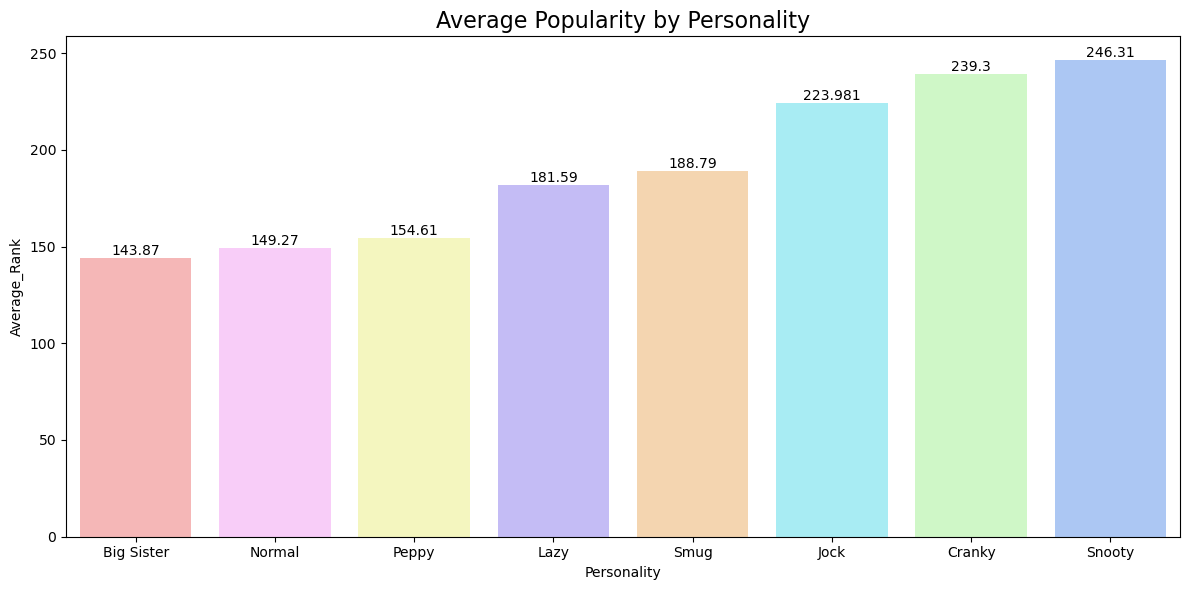

In [114]:
data = [143.87, 149.27, 154.61, 181.59, 188.79, 223.981481, 239.3, 246.31]
labels = ['Big Sister', 'Normal', 'Peppy', 'Lazy', 'Smug', 'Jock', 'Cranky', 'Snooty']
palette = ['#ffadad', '#ffc6ff', '#fdffb6',  '#bdb2ff', '#ffd6a5', '#9bf6ff', '#caffbf', '#a0c4ff']
plt.figure(figsize=(12, 6))
graph = sns.barplot(x=labels, y=data, hue=data, palette=sns.color_palette(palette))
for i in graph.containers:
    graph.bar_label(i)
graph.get_legend().remove()
plt.title('Average Popularity by Personality', fontsize=16)
plt.xlabel('Personality')
plt.ylabel('Average_Rank')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Big Sister and Smug having notably smaller percentages is unsurprising, as they were only added in the second-most recent installation in the series, New Leaf. Otherwise, the distribution is relatively even, although Peppy is slightly behind.